In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mpl_toolkits.mplot3d as Axes3D

 length of x  2930 
 length of y  2930


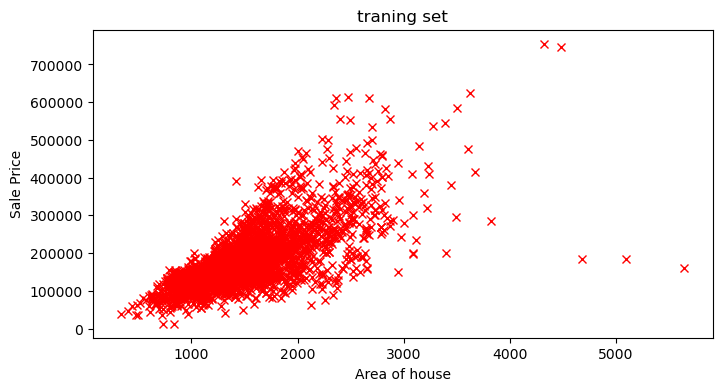

In [2]:
dataset=pd.read_csv("AmesHousing.csv")

x=dataset["Gr Liv Area"]
y=dataset["SalePrice"]
nx=len(x)
ny=len(y)

print(" length of x ",nx,"\n","length of y ",ny)

plt.figure(figsize=(8,4))
plt.plot(x,y,color="red",marker="x",linestyle="none")
plt.xlabel("Area of house")
plt.ylabel("Sale Price")
plt.title("traning set")
plt.show()

In [3]:
w_vals=np.linspace(-1000,1000,100)
b_vals=np.linspace(-500000,700000,100)
W,B=np.meshgrid(w_vals,b_vals)
m=nx
J_wb=np.zeros_like(W)

for i in range (W.shape[0]):
    for j in range (W.shape[1]):
        y_hat=W[i,j]*x+B[i,j]
        error=y_hat-y
        J_wb[i,j]=(1/(2*m))*(error**2).sum()

so we have an array w and b and we are using both to create a mesh gird whoes axes will be W and B and now W and B both are a 100x100 grid.
what we want next is to get a particular scalar value of both w and b and put it through all values to x to get a y_hat for that particular value of w and b over the whole traning set and than calculate the error and sum up all the errors of traning set associated with that particular value of w and b to get a single normalized error at that w and b value. And we have to do it for all values of w and b in the grid.

so for loops get the particular values of w and b from grid and at the end calculate the cost function for each point. W.shape()=(100,100) returns 
(numer of rows, number of columns) W.shape[0] gives the number of rows, W.shape[1] returns number of columns hence both for loops ensure we have covered complete grid.

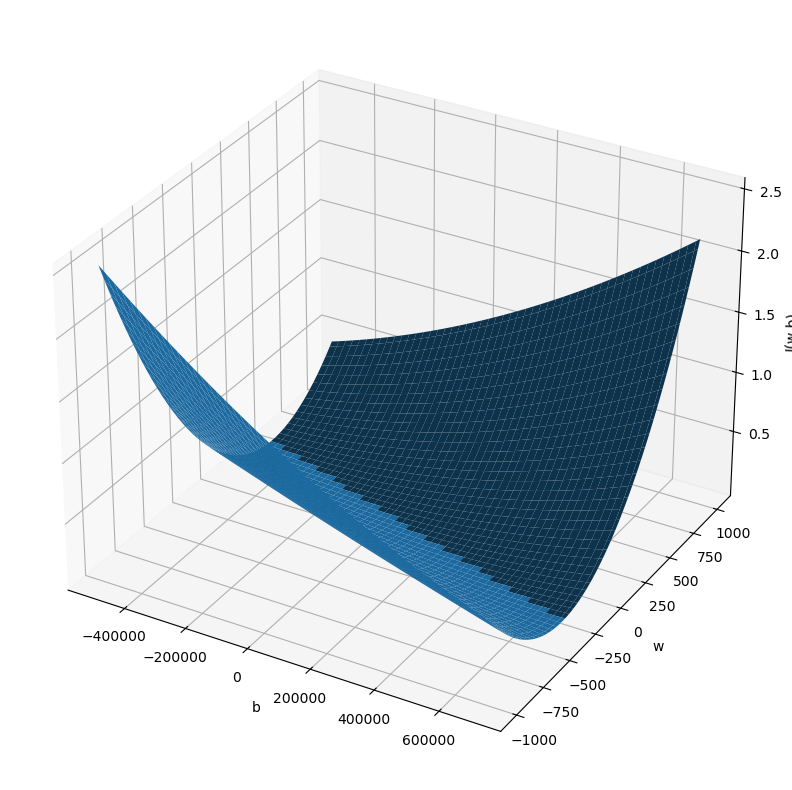

In [4]:
plt.ion()
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(B,W,J_wb)
ax.set_xlabel("b")
ax.set_ylabel("w")
ax.set_zlabel("J(w,b)")
plt.show()

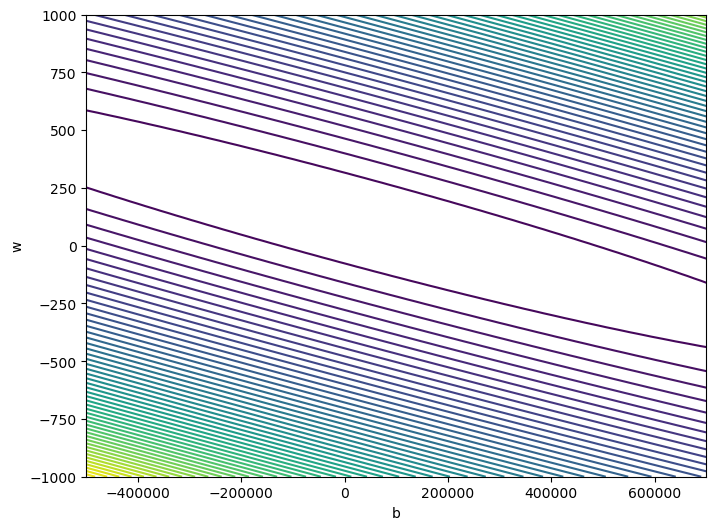

In [5]:
plt.figure(figsize=(8,6))
plt.contour(B, W, J_wb, levels=50)
plt.xlabel("b")
plt.ylabel("w")
plt.show()

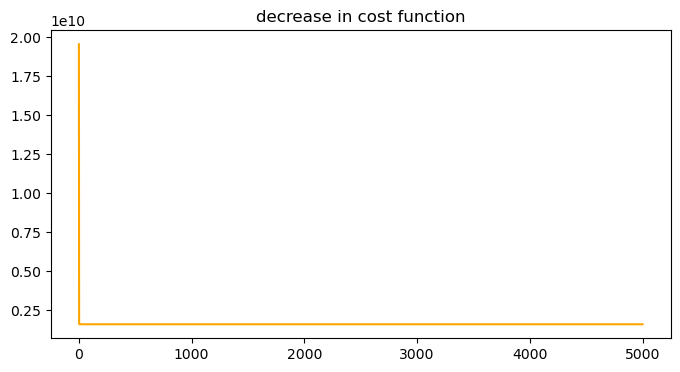

value of w  119.64966590391819 
value of b  3.4599276120870055


In [6]:
alpha=5e-7
ini_w=0;ini_b=0
num_iter=5000
temp=np.zeros(num_iter)
temp_x=np.arange(num_iter)
w=ini_w;b=ini_b
for k in range (num_iter):
    y_hat=w*x+b
    error=y_hat-y
    J_wb=(1/(2*m))*(error**2).sum()
    temp[k]=J_wb
    
    gradient_w=(1/m)*(error*x).sum()
    gradient_b=(1/m)*error.sum()
    
    w=w-alpha*gradient_w
    b=b-alpha*gradient_b

plt.figure(figsize=(8,4))
plt.plot(temp_x,temp,color="orange")
plt.title("decrease in cost function")
plt.show()
print("value of w ",w,"\nvalue of b ",b)

model equation: 119.6497 x + 3.4599


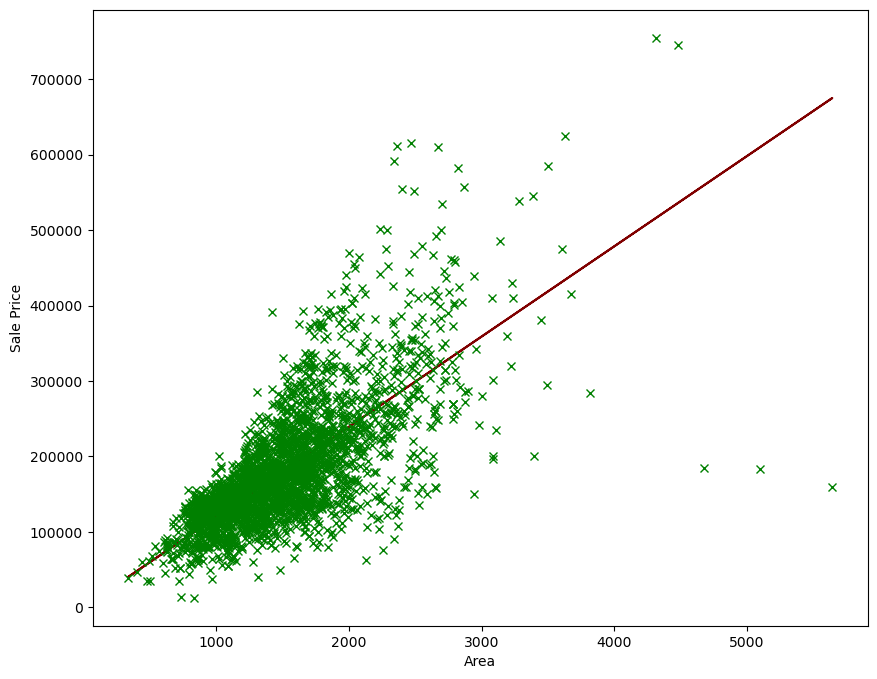

In [7]:
print(f"model equation: {w:.4f} x + {b:.4f}")
plt.figure(figsize=(10,8))
plt.plot(x,y_hat,color="maroon")
plt.plot(x,y,linestyle="none",color="green",marker="x")
plt.ylabel("Sale Price")
plt.xlabel("Area")
plt.show()

from here starts the model's prediction:

In [8]:
a=float(input("Enter the Area of house: "))
prediction=w*a+b

Enter the Area of house:  2000


In [9]:
print(f"According the the House Area: {a} the price should be approx {prediction:.4f}")

According the the House Area: 2000.0 the price should be approx 239302.7917
